**Chapter 11 – Training Deep Neural Networks**

This chapter introduces techniques for training deep neural networks effectively, addressing challenges like vanishing and exploding gradients. You'll explore initialization methods, activation functions (such as ReLU variants), batch normalization, gradient clipping, transfer learning, and advanced optimizers like Adam. These tools help build stable, high-performing models on complex datasets.

_This notebook contains all the sample code and solutions to the exercises in chapter 11._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/11_training_deep_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/11_training_deep_neural_networks.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

And TensorFlow ≥ 2.8:

In [2]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/deep` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "deep"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

---

# Vanishing/Exploding Gradients Problem

When training deep neural networks, gradients can become **very small (vanish)** or **very large (explode)** as they are backpropagated through many layers. This can lead to slow learning or unstable updates, making it difficult for the network to converge to a good solution.

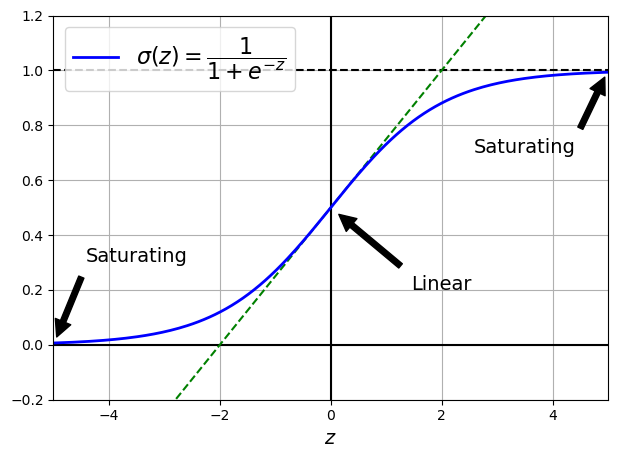

In [5]:
# extra code – this cell generates and saves Figure 11–1

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

save_fig("sigmoid_saturation_plot")
plt.show()

This plot illustrates the **sigmoid activation function** ($\sigma(z) = \frac{1}{1 + e^{-z}}$), which is commonly used in neural networks but *suffers from the vanishing gradients problem* in deep networks. The function saturates (becomes flat) at extreme values of $z$ (near -5 and +5), where the derivative approaches 0. This causes gradients to vanish during backpropagation, slowing learning in deep layers. The annotations highlight the "saturating" regions and the "linear" region around $z=0$, where gradients are stronger. This visualization supports the discussion on why better initialization and activation functions are needed for deep networks.

---

## Xavier (Glorot) and He Initialization

To mitigate the vanishing/exploding gradients problem, we can use specialized weight initialization methods like **Xavier (Glorot) initialization** for activation functions like tanh and sigmoid, and **He initialization** for ReLU and its variants. These methods help maintain a stable variance of activations and gradients throughout the network.

First, let's create a dense layer with ReLU activation and He normal initialization:

In [6]:
dense = tf.keras.layers.Dense(50, activation="relu",
                              kernel_initializer="he_normal")

This code creates a dense (fully connected) layer with 50 neurons, using the ReLU activation function and He normal initialization for the weights. He initialization helps prevent vanishing gradients in deep networks by scaling the weights appropriately for ReLU activations, maintaining stable variance across layers. This is a common technique for training deep neural networks effectively.
`kernel_initializer="he_normal"` specifies that the weights should be initialized using the He normal method.

In [7]:
he_avg_init = tf.keras.initializers.VarianceScaling(scale=2., mode="fan_avg",
                                                    distribution="uniform")
dense = tf.keras.layers.Dense(50, activation="sigmoid",
                              kernel_initializer=he_avg_init)

Furthermore, a custom He initialization variant for a dense layer using the sigmoid activation function is instantiated. The `VarianceScaling` initializer is configured with `scale=2.0` (suitable for sigmoid, which is similar to Xavier/Glorot initialization), `mode="fan_avg"` (averages fan-in and fan-out), and `distribution="uniform"` for uniform weight distribution. This helps stabilize gradients in deep networks, though He initialization is more commonly used with ReLU. The layer has 50 neurons and sigmoid activation.

Secondly, we can use **Xavier initialization** for a dense layer with the tanh activation function as follows:


In [8]:
from tensorflow import keras
layer = keras.layers.Dense(
    50,
    activation="tanh",
    kernel_initializer=keras.initializers.GlorotUniform(),
)

where `kernel_initializer=keras.initializers.GlorotUniform()` specifies Xavier uniform initialization. Equivalently, you could use `GlorotNormal()` for normal distribution.

In [9]:
layer = keras.layers.Dense(
    50,
    activation="sigmoid",
    kernel_initializer=keras.initializers.VarianceScaling(
        scale=2.0, mode="fan_avg", distribution="uniform"
    ),
)

This code creates a dense layer with 50 neurons using the sigmoid activation function and a custom Xavier initialization variant. The `VarianceScaling` initializer is set with `scale=2.0` (appropriate for sigmoid, matching Xavier/Glorot scaling), `mode="fan_avg"` (averaging fan-in and fan-out), and `distribution="uniform"` for uniform weight distribution. This helps stabilize gradients in deep networks, though Xavier is typically used with tanh or sigmoid. The layer is defined using TensorFlow's Keras API.

---

## Nonsaturating Activation Functions

Using nonsaturating activation functions like ReLU and its variants (Leaky ReLU, ELU, SELU) helps mitigate the vanishing gradients problem. These functions do not saturate for positive inputs, allowing gradients to flow more easily through deep networks.

### Leaky ReLU

This code creates a dense layer with 50 neurons using the Leaky ReLU activation function, which allows a small, non-zero gradient when the input is negative. This helps prevent neurons from "dying" during training, addressing issues associated with the standard ReLU function.

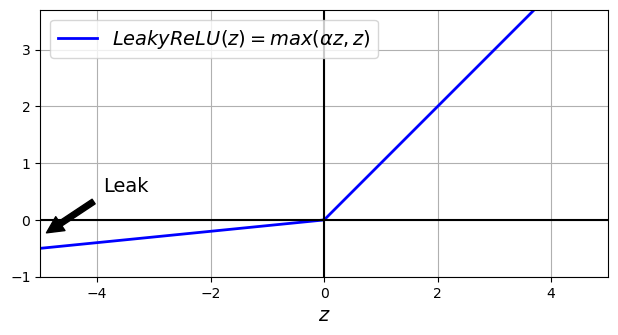

In [10]:
# extra code – this cell generates and saves Figure 11–2

def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

save_fig("leaky_relu_plot")
plt.show()

This plot displays the **Leaky ReLU activation function**, defined as $max(\alpha z, z)$, where $\alpha$ (alpha) is a small positive constant (typically 0.1, as indicated by the plot's slope for $z < 0$).

Unlike the standard ReLU function which outputs 0 for negative inputs, Leaky ReLU allows a small, non-zero gradient for negative values. This "leak" (highlighted in the annotation) prevents neurons from becoming inactive (or "dying") when their input is negative, which can happen with standard ReLU. By maintaining a non-zero gradient across all inputs, Leaky ReLU helps mitigate the **vanishing gradients problem** and allows for more stable and efficient training of deep neural networks.

In [11]:
leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.2)  # defaults to alpha=0.3
dense = tf.keras.layers.Dense(50, activation=leaky_relu,
                              kernel_initializer="he_normal")

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [12]:
model = tf.keras.models.Sequential([
    # [...]  # more layers
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # no activation
    tf.keras.layers.LeakyReLU(alpha=0.2),  # activation as a separate layer
    # [...]  # more layers
])

### ELU

This code creates a dense layer with 50 neurons using the **Exponential Linear Unit (ELU)** activation function. ELU helps mitigate the vanishing gradients problem by allowing negative outputs for negative inputs, which helps maintain a non-zero gradient. This can lead to faster convergence and improved performance in deep neural networks compared to standard ReLU.
The ELU is defined as:

$$
\mathrm{ELU}_\alpha(z)=
\begin{cases}
z & \text{if } z \ge 0,\\[6pt]
\alpha\big(e^{z}-1\big) & \text{if } z < 0,
\end{cases}
$$

and its derivative is

$$
\mathrm{ELU}'_\alpha(z)=
\begin{cases}
1 & \text{if } z \ge 0,\\[6pt]
\alpha\,e^{z} & \text{if } z < 0.
\end{cases}
$$

Notes: the negative part is bounded below by −α, the derivative is continuous at 0 when α = 1 (the common default), and ELU yields nonzero gradients for z < 0, helping training stability.

Implementing ELU in TensorFlow is trivial, just specify the activation function when building each layer, and use He initialization:

In [13]:
dense = tf.keras.layers.Dense(50, activation="elu",
                              kernel_initializer="he_normal")

### SELU

By default, the SELU hyperparameters (`scale` and `alpha`) are tuned in such a way that the mean output of each neuron remains close to 0, and the standard deviation remains close to 1 (assuming the inputs are standardized with mean 0 and standard deviation 1 too, and other constraints are respected, as explained in the book). Using this activation function, even a 1,000 layer deep neural network preserves roughly mean 0 and standard deviation 1 across all layers, avoiding the exploding/vanishing gradients problem:

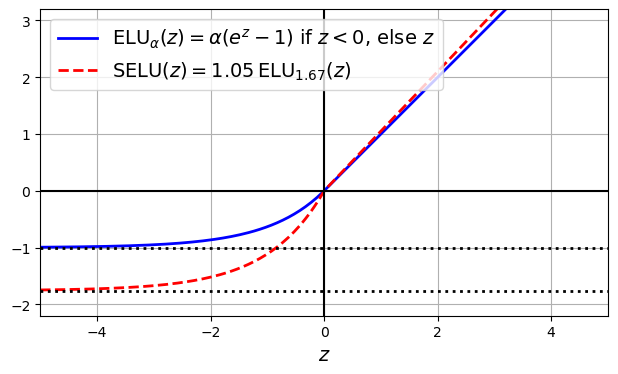

In [14]:
# extra code – this cell generates and saves Figure 11–3

from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
# (see equation 14 in the paper):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

save_fig("elu_selu_plot")
plt.show()

Using SELU is straightforward:

In [15]:
dense = tf.keras.layers.Dense(50, activation="selu",
                              kernel_initializer="lecun_normal")

**Extra material – an example of a self-regularized network using SELU**

Let's create a neural net for Fashion MNIST with 100 hidden layers, using the SELU activation function:

In [16]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="selu",
                                    kernel_initializer="lecun_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

Now let's train it. Do not forget to scale the inputs to mean 0 and standard deviation 1:

In [18]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [19]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [20]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [21]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.5834 - loss: 1.0949 - val_accuracy: 0.7394 - val_loss: 0.7258
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7544 - loss: 0.6776 - val_accuracy: 0.7808 - val_loss: 0.6113
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7915 - loss: 0.5842 - val_accuracy: 0.7982 - val_loss: 0.5821
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8180 - loss: 0.5223 - val_accuracy: 0.8202 - val_loss: 0.5159
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8309 - loss: 0.4886 - val_accuracy: 0.8344 - val_loss: 0.4775


The network managed to learn, despite how deep it is. Now look at what happens if we try to use the ReLU activation function instead:

In [22]:
tf.random.set_seed(42)

In [23]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="relu",
                                    kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [24]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

In [25]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.2381 - loss: 2.0383 - val_accuracy: 0.3894 - val_loss: 1.7483
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4431 - loss: 1.5171 - val_accuracy: 0.5384 - val_loss: 1.1896
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5607 - loss: 1.0892 - val_accuracy: 0.6202 - val_loss: 0.9683
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6004 - loss: 1.0243 - val_accuracy: 0.6814 - val_loss: 0.8409
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6733 - loss: 0.8381 - val_accuracy: 0.7036 - val_loss: 0.7852


Not great at all, we suffered from the vanishing/exploding gradients problem.

### GELU, Swish and Mish

This code creates a dense layer with 50 neurons using the **GELU (Gaussian Error Linear Unit)** activation function. GELU is a smooth, non-linear activation function that combines properties of *ReLU and sigmoid functions*. It helps mitigate the vanishing gradients problem by allowing small negative outputs, which can improve training stability and performance in deep neural networks.

where the GELU activation is defined as:
$$\mathrm{GELU}(z) = 0.5z\left(1 + \mathrm{tanh}\left[\sqrt{\frac{2}{\pi}}\left(z + 0.044715z^3\right)\right]\right)$$


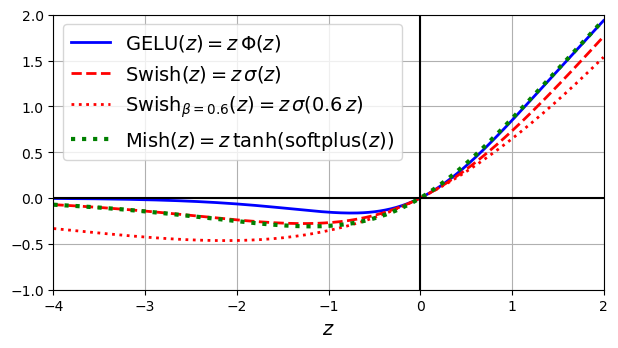

In [26]:
# extra code – this cell generates and saves Figure 11–4

def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

z = np.linspace(-4, 2, 200)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

save_fig("gelu_swish_mish_plot")
plt.show()

This plot compares three smooth, non‑saturating activations (and a Swish variant) over z ∈ [−4, 2]:

- Blue (approx GELU): GELU ≈ z·Φ(z). smooth, nearly linear for positive z, yields small negative outputs for negative z — used in Transformers (BERT).  
- Red (Swish, β=1 — dashed; β=0.6 — dotted): swish(z)=z·σ(βz). smooth, can be non‑monotonic; β controls the “leak” for negatives (smaller β → smaller negative response). Swish with β≈1.702 closely approximates GELU.  
- Green (Mish): z·tanh(softplus(z)). smooth, non‑monotonic, produces mild negative tail and very smooth transitions.

Key observations and practical implications
- All three preserve nonzero gradients for negative inputs (unlike ReLU), improving gradient flow and representation richness in deep nets.  
- Differences are subtle for moderate z but can affect optimization dynamics and generalization; non‑monotonicity can act like a mild implicit regularizer.  
- Computational cost: GELU/Swish/Mish > ReLU; GELU and Swish are commonly implemented and well‑optimized (GELU standard in NLP; Swish used in state‑of‑the‑art vision nets like EfficientNet). Mish is promising but less ubiquitous.  
- Recommendation: prefer GELU for Transformer/NLP work, try Swish (tune β) for vision, consider Mish as an experimental alternative — always validate on your task and monitor training speed and generalization.

---

# Batch Normalization

Batch normalization **standardizes the inputs to each layer**, stabilizing learning and allowing for higher learning rates. It helps mitigate internal covariate shift, improving convergence speed and model performance.

In [27]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [28]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.BatchNormalization(), # standardize inputs
    tf.keras.layers.Dense(300, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(), # standardize inputs
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(), # standardize inputs
    tf.keras.layers.Dense(10, activation="softmax")
])

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [30]:
[(var.name, var.trainable) for var in model.layers[1].variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

In [31]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8102 - loss: 0.5491 - val_accuracy: 0.8586 - val_loss: 0.3920
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8613 - loss: 0.3926 - val_accuracy: 0.8704 - val_loss: 0.3604


In [32]:
[(var.name, var.trainable) for var in model.layers[1].variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

Sometimes applying BN *before the activation function works better* (there's a debate on this topic). Moreover, the layer before a `BatchNormalization` layer does not need to have bias terms, since the `BatchNormalization` layer some as well, it would be a waste of parameters, so you can set `use_bias=False` when creating those layers:

In [33]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),

    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(), # BN before activation
    tf.keras.layers.Activation("relu"),
    
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(), # BN before activation
    tf.keras.layers.Activation("relu"),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8012 - loss: 0.5955 - val_accuracy: 0.8382 - val_loss: 0.4394
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8550 - loss: 0.4182 - val_accuracy: 0.8538 - val_loss: 0.3975


## Gradient Clipping

To prevent exploding gradients during training, we can use gradient clipping. This technique limits the maximum value of gradients, ensuring stable updates to the model weights.

All `tf.keras.optimizers` accept `clipnorm` or `clipvalue` arguments:

In [36]:
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

### `clipnorm` (concise explanation)

- What it does  
  Clips the global $\ell_2$ norm of the gradient vector for an update. If the total gradient norm $\lVert g\rVert_2$ exceeds the threshold $c$, all gradients are rescaled by $c / \lVert g\rVert_2$:

  $$
  g \leftarrow
  \begin{cases}
    g, & \text{if }\ \lVert g\rVert_2 \le c,\\[6pt]
    g \cdot \dfrac{c}{\lVert g\rVert_2}, & \text{otherwise.}
  \end{cases}
  $$

- How Keras applies it  
  `tf.keras` uses a global‑norm clip (`tf.clip_by_global_norm`) on the gradients computed for the current batch — i.e., it scales the whole gradient tuple together (based on $\lVert g\rVert_2$).

- Difference vs. `clipvalue`  
  - `clipnorm`: rescales the entire gradient vector when its $\ell_2$ norm is too large (preserves direction).  
  - `clipvalue`: clips each gradient component element‑wise to the range $[-c,\,c]$ (may change direction).

- When to use  
  - Prevent exploding gradients (RNNs, very deep nets, unstable training).  
  - Use when you observe very large gradient norms or unstable loss/weight updates.

- Typical settings and tips
  - Common starting value: `clipnorm ≈ 1.0` (tune for your model).  
  - Works with any optimizer (SGD, Adam, etc.).  
  - Does not fix vanishing gradients — only bounds explosion.  
  - Monitor gradient norms with e.g. `tf.linalg.global_norm` to choose an appropriate threshold.

- Keras example  
  - `optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)`

In [37]:
optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

## Reusing Pretrained Layers

### Reusing a Keras model

Let's split the fashion MNIST training set in two:
* `X_train_A`: all images of all items except for T-shirts/tops and pullovers (classes 0 and 2).
* `X_train_B`: a much smaller training set of just the first 200 images of T-shirts/tops and pullovers.

The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using `Dense` layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image, as we will see in the chapter 14).

In [38]:
# extra code – split Fashion MNIST into tasks A and B, then train and save
#              model A to "my_model_A".

pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

tf.random.set_seed(42)

model_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))
model_A.save("my_model_A.keras")

Epoch 1/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6388 - loss: 1.1256 - val_accuracy: 0.7754 - val_loss: 0.6849
Epoch 2/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8007 - loss: 0.5999 - val_accuracy: 0.8260 - val_loss: 0.5212
Epoch 3/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8394 - loss: 0.4910 - val_accuracy: 0.8481 - val_loss: 0.4494
Epoch 4/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8593 - loss: 0.4325 - val_accuracy: 0.8599 - val_loss: 0.4067
Epoch 5/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8709 - loss: 0.3947 - val_accuracy: 0.8689 - val_loss: 0.3782
Epoch 6/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8780 - loss: 0.3682 - val_accuracy: 0.8742 - val_loss: 0.3577
Epoch 7/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8836 - loss: 0.3486 - val_accuracy: 0.8794 - val_loss: 0.3426
Epoch 8/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8880 - loss: 0.3335 - 

In [39]:
# extra code – train and evaluate model B, without reusing model A

tf.random.set_seed(42)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))
model_B.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4450 - loss: 0.7060 - val_accuracy: 0.4946 - val_loss: 0.6402
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4600 - loss: 0.6445 - val_accuracy: 0.5500 - val_loss: 0.5960
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5700 - loss: 0.5991 - val_accuracy: 0.6785 - val_loss: 0.5625
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7350 - loss: 0.5636 - val_accuracy: 0.8081 - val_loss: 0.5355
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8400 - loss: 0.5350 - val_accuracy: 0.8694 - val_loss: 0.5144
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8650 - loss: 0.5125 - val_accuracy: 0.8922 - val_loss: 0.4965
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8850 - loss: 0.4934 - val_accuracy: 0.9011 - val_loss: 0.4802
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9000 - loss: 0.4760 - val_accuracy: 0.9130 - val_loss: 0.4653


[0.34875839948654175, 0.9359999895095825]

Model B reaches 91.85% accuracy on the test set. Now let's try reusing the pretrained model A.

In [40]:
model_A = tf.keras.models.load_model("my_model_A.keras")
model_B_on_A = tf.keras.Sequential(model_A.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

Note that `model_B_on_A` and `model_A` actually share layers now, so when we train one, it will update both models. If we want to avoid that, we need to build `model_B_on_A` on top of a *clone* of `model_A`:

In [41]:
tf.random.set_seed(42)  # extra code – ensure reproducibility

In [42]:
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [43]:
# extra code – creating model_B_on_A just like in the previous cell
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [44]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])

In [45]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))

Epoch 1/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4500 - loss: 0.9320 - val_accuracy: 0.4936 - val_loss: 0.7628
Epoch 2/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4700 - loss: 0.7500 - val_accuracy: 0.5312 - val_loss: 0.6946
Epoch 3/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5600 - loss: 0.6963 - val_accuracy: 0.5865 - val_loss: 0.6718
Epoch 4/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6100 - loss: 0.6739 - val_accuracy: 0.6202 - val_loss: 0.6576
Epoch 1/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6700 - loss: 0.6347 - val_accuracy: 0.7280 - val_loss: 0.5883
Epoch 2/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8150 - loss: 0.5648 - val_accuracy: 0.8101 - val_loss: 0.5334
Epoch 3/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8800 - loss: 0.5103 - val_accuracy: 0.8487 - val_loss: 0.4909
Epoch 4/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9000 - loss: 0.4680 - val_accuracy: 0.8773 - val_loss: 0.4570
Epoc

So, what's the final verdict?

In [46]:
model_B_on_A.evaluate(X_test_B, y_test_B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9235 - loss: 0.2930


[0.29300180077552795, 0.9235000014305115]

Great! We got a bit of transfer: the model's accuracy went up 2 percentage points, from 91.85% to 93.85%. This means the error rate dropped by almost 25%:

In [47]:
1 - (100 - 93.85) / (100 - 91.85)

0.24539877300613477

---

# Faster Optimizers

Faster optimizers aim to converge in fewer epochs (and with less tuning) while still generalizing well. This section compares popular algorithms, summarizes their trade‑offs, and gives a practical workflow for picking and tuning an optimizer.

Key algorithms (very briefly)
- SGD + momentum / Nesterov — simple, robust; often yields the best final generalization but can be slower to converge. Typical: momentum=0.9.
- RMSProp — adaptive per‑parameter steps; good for noisy/ill‑conditioned problems.
- Adam / AdamW — fast, well‑behaved defaults for prototyping; AdamW decouples weight decay (preferred for regularization).
- Nadam / AMSGrad — small variants that can help stability in some cases.

Practical recipe
- Prototype with Adam (lr ≈ 1e‑3) to find a reasonable model and learning‑rate range.
- For best final results, switch to SGD + momentum (momentum ≈ 0.9) and use a tuned LR schedule (step decay, cosine annealing, or cyclic).
- Use AdamW (not plain Adam with L2) when using decoupled weight decay.
- For large‑batch training use learning‑rate warmup; scale LR proportionally to batch size.
- Clip gradients (clipnorm ≈ 1.0) if you see unstable/very large updates.
- Always perform a small LR sweep (log scale) and run multiple seeds for robustness.

Typical starting hyperparameters
- SGD: lr 0.01–0.1, momentum 0.9
- Adam: lr 1e‑3, beta1=0.9, beta2=0.999, eps=1e‑7–1e‑8
- AdamW: same as Adam, weight_decay ≈ 1e‑2
- RMSProp: lr 1e‑3, rho 0.9

What you will see next
- Automated comparisons (same architecture, same seed) to evaluate convergence speed and final validation accuracy on Fashion MNIST.
- Suggested experiments: LR sweeps, train longer with SGD+momentum, and compare learning curves and wall‑clock time.

In [48]:
# extra code – a little function to test an optimizer on Fashion MNIST

def build_model(seed=42):
    """Builds a simple neural network model for Fashion MNIST.

    Args:
        seed (int, optional): Random seed for reproducibility. Defaults to 42.

    Returns:
        tf.keras.Sequential: A compiled Keras Sequential model with three dense layers.
    """
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def build_and_train_model(optimizer):
    """Builds, compiles, and trains a model using the given optimizer.

    Args:
        optimizer: A TensorFlow optimizer instance to use for training.

    Returns:
        A History object containing the training history.
    """
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

In [49]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

In [50]:
history_sgd = build_and_train_model(optimizer)  # extra code

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5947 - loss: 1.3405 - val_accuracy: 0.7084 - val_loss: 0.8738
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7239 - loss: 0.7862 - val_accuracy: 0.7654 - val_loss: 0.6983
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7747 - loss: 0.6678 - val_accuracy: 0.7942 - val_loss: 0.6182
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7982 - loss: 0.6036 - val_accuracy: 0.8076 - val_loss: 0.5707
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8103 - loss: 0.5629 - val_accuracy: 0.8156 - val_loss: 0.5392
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8182 - loss: 0.5342 - val_accuracy: 0.8226 - val_loss: 0.5163
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8246 - loss: 0.5129 - val_accuracy: 0.8252 - val_loss: 0.4989
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8296 - loss: 0.4964 - 

### Momentum optimization

- What it does  
  Accelerates gradient descent by adding a fraction β of the previous update (velocity) to the current update, helping to navigate ravines and speed convergence while reducing oscillations.

- Update rule
  $$
  \mathbf{v} \leftarrow \beta \mathbf{v} + \eta \nabla_\theta \mathcal{L}(\theta)
  $$
  $$
  \theta \leftarrow \theta - \mathbf{v}
  $$

- Typical settings and tips  
  - Common value: β ≈ 0.9; tune the learning rate η accordingly.  
  - If β is too close to 1, the optimizer may overshoot and oscillate.  
  - Use with SGD for better final generalization when combined with a tuned LR schedule.

In [51]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

In [52]:
history_momentum = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7590 - loss: 0.7044 - val_accuracy: 0.8240 - val_loss: 0.4928
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8355 - loss: 0.4690 - val_accuracy: 0.8430 - val_loss: 0.4421
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8509 - loss: 0.4218 - val_accuracy: 0.8512 - val_loss: 0.4141
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8598 - loss: 0.3932 - val_accuracy: 0.8540 - val_loss: 0.3981
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8673 - loss: 0.3731 - val_accuracy: 0.8578 - val_loss: 0.3867
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8719 - loss: 0.3575 - val_accuracy: 0.8614 - val_loss: 0.3808
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8768 - loss: 0.3443 - val_accuracy: 0.8654 - val_loss: 0.3745
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8799 - loss: 0.3330 - 

## Nesterov Accelerated Gradient

- What it does  
    A variant of momentum that computes gradients at the anticipated future position, leading to more informed updates and often faster convergence.

- Update rule
    $$
    \mathbf{v} \leftarrow \beta \mathbf{v} - \eta \nabla_\theta \mathcal{L}(\theta + \beta \mathbf{v})
    $$
    $$
    \theta \leftarrow \theta + \mathbf{v}
    $$

- Typical settings and tips  
    - Common value: β ≈ 0.9; tune the learning rate η accordingly.  
    - Often outperforms standard momentum, especially in convex problems.  
    - Use with SGD for better final generalization when combined with a tuned LR schedule.

In [53]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9,
                                    nesterov=True)

In [54]:
history_nesterov = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7609 - loss: 0.6952 - val_accuracy: 0.8254 - val_loss: 0.4907
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8387 - loss: 0.4542 - val_accuracy: 0.8432 - val_loss: 0.4401
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8538 - loss: 0.4118 - val_accuracy: 0.8524 - val_loss: 0.4129
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8625 - loss: 0.3861 - val_accuracy: 0.8570 - val_loss: 0.3958
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8685 - loss: 0.3673 - val_accuracy: 0.8590 - val_loss: 0.3845
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8742 - loss: 0.3522 - val_accuracy: 0.8642 - val_loss: 0.3772
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8787 - loss: 0.3394 - val_accuracy: 0.8666 - val_loss: 0.3697
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8823 - loss: 0.3285 - 

## AdaGrad

- What it does  
    Adapts the learning rate for each parameter based on the historical sum of squared gradients, allowing larger updates for infrequent parameters and smaller updates for frequent ones.

- Update rule
    $$
        \mathbf{s}_t = \mathbf{s}_{t-1} + \mathbf{g}_t^2
    $$
    $$
        \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\mathbf{s}_t} + \epsilon} \mathbf{g}_t
    $$

- Typical settings and tips  
    - Initial learning rate η often set around 0.01.  
    - ε is a small constant (e.g., 1e‑7) to prevent division by zero.  
    - Can lead to overly small learning rates over time; consider using RMSProp or Adam for better long‑term performance.

In [55]:
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)

In [56]:
history_adagrad = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6569 - loss: 1.0776 - val_accuracy: 0.7666 - val_loss: 0.7135
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7761 - loss: 0.6629 - val_accuracy: 0.8002 - val_loss: 0.6004
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8006 - loss: 0.5864 - val_accuracy: 0.8104 - val_loss: 0.5508
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8139 - loss: 0.5459 - val_accuracy: 0.8208 - val_loss: 0.5215
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8218 - loss: 0.5200 - val_accuracy: 0.8272 - val_loss: 0.5019
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8279 - loss: 0.5017 - val_accuracy: 0.8312 - val_loss: 0.4877
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8323 - loss: 0.4877 - val_accuracy: 0.8346 - val_loss: 0.4764
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8359 - loss: 0.4765 - 

## RMSProp

- What it does  
    Adapts the learning rate for each parameter by dividing the gradient by a running average of its recent magnitudes, helping to handle non-stationary objectives and reducing oscillations in ravines.

- Update rule
    $$
        \mathbf{s}_t = \rho \mathbf{s}_{t-1} + (1 - \rho) \mathbf{g}_t^2
    $$
    $$
        \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\mathbf{s}_t} + \epsilon} \mathbf{g}_t
    $$

- Typical settings and tips  
    - Common values: ρ ≈ 0.9, η ≈ 0.001, ε ≈ 1e‑7.  
    - Often performs well on recurrent networks and noisy problems.  
    - Can be combined with momentum for further improvements; consider Adam for more robust adaptive behavior.

In [57]:
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

In [58]:
history_rmsprop = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8166 - loss: 0.5093 - val_accuracy: 0.8476 - val_loss: 0.4043
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8616 - loss: 0.3883 - val_accuracy: 0.8676 - val_loss: 0.3755
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8707 - loss: 0.3618 - val_accuracy: 0.8546 - val_loss: 0.4122
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8776 - loss: 0.3503 - val_accuracy: 0.8480 - val_loss: 0.4394
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8809 - loss: 0.3430 - val_accuracy: 0.8610 - val_loss: 0.4221
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8797 - loss: 0.3413 - val_accuracy: 0.8604 - val_loss: 0.4392
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8841 - loss: 0.3383 - val_accuracy: 0.8612 - val_loss: 0.4318
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8834 - loss: 0.3399 - 

## Adam Optimization
- What it does  
    Combines momentum and RMSProp ideas: adapts learning rates per parameter using exponentially weighted averages of past gradients and squared gradients, making it effective for a wide range of problems.

- Update rule  
    $$
    \mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t
    $$
    $$
    \mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2
    $$
    $$
    \hat{\mathbf{m}}_t = \dfrac{\mathbf{m}_t}{1 - \beta_1^t}
    $$
    $$
    \hat{\mathbf{v}}_t = \dfrac{\mathbf{v}_t}{1 - \beta_2^t}
    $$
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} \hat{\mathbf{m}}_t
    $$

- Typical settings and tips  
    - Common values: η ≈ 0.001, β1 ≈ 0.9, β2 ≈ 0.999, ε ≈ 1e−8.  
    - Often works well out of the box; consider AdamW for decoupled weight decay.  
    - Can converge quickly but may generalize worse than SGD+momentum; tune carefully.

In [59]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9,
                                     beta_2=0.999)

In [60]:
history_adam = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8215 - loss: 0.5020 - val_accuracy: 0.8374 - val_loss: 0.4161
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8628 - loss: 0.3750 - val_accuracy: 0.8356 - val_loss: 0.4058
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8750 - loss: 0.3389 - val_accuracy: 0.8534 - val_loss: 0.3804
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8825 - loss: 0.3161 - val_accuracy: 0.8614 - val_loss: 0.3684
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8897 - loss: 0.2977 - val_accuracy: 0.8638 - val_loss: 0.3585
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8960 - loss: 0.2805 - val_accuracy: 0.8656 - val_loss: 0.3813
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8994 - loss: 0.2685 - val_accuracy: 0.8686 - val_loss: 0.3719
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9030 - loss: 0.2569 - 

## Adamax Optimization

- What it does  
    A variant of Adam that uses the infinity norm for the second moment instead of the L2 norm, making it more robust to large gradients and potentially better for certain problems like natural language processing.

- Update rule  
    $$
    \mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t
    $$
    $$
    \mathbf{v}_t = \max(\beta_2 \mathbf{v}_{t-1}, |\mathbf{g}_t|)
    $$
    $$
    \hat{\mathbf{m}}_t = \dfrac{\mathbf{m}_t}{1 - \beta_1^t}
    $$
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\mathbf{v}_t} \hat{\mathbf{m}}_t
    $$

- Typical settings and tips  
    - Common values: η ≈ 0.001, β1 ≈ 0.9, β2 ≈ 0.999.  
    - Similar to Adam but can be more stable for sparse gradients; consider it as an alternative when Adam's L2 norm causes issues.  
    - Often used in NLP tasks; tune learning rate and monitor convergence.


In [61]:
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9,
                                       beta_2=0.999)

In [62]:
history_adamax = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8141 - loss: 0.5290 - val_accuracy: 0.8432 - val_loss: 0.4222
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8583 - loss: 0.3950 - val_accuracy: 0.8520 - val_loss: 0.3916
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8719 - loss: 0.3563 - val_accuracy: 0.8554 - val_loss: 0.3779
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8811 - loss: 0.3306 - val_accuracy: 0.8632 - val_loss: 0.3623
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8876 - loss: 0.3115 - val_accuracy: 0.8642 - val_loss: 0.3581
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8929 - loss: 0.2959 - val_accuracy: 0.8620 - val_loss: 0.3569
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8973 - loss: 0.2827 - val_accuracy: 0.8644 - val_loss: 0.3495
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9015 - loss: 0.2712 - 

## Nadam Optimization
- What it does  
    Combines Adam's adaptive learning rates with Nesterov's accelerated gradient, computing gradients at the anticipated future position for more informed updates and faster convergence.

- Update rule  
    $$
    \mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t
    $$
    $$
    \mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2
    $$
    $$
    \hat{\mathbf{m}}_t = \dfrac{\mathbf{m}_t}{1 - \beta_1^t}
    $$
    $$
    \hat{\mathbf{v}}_t = \dfrac{\mathbf{v}_t}{1 - \beta_2^t}
    $$
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} (\beta_1 \hat{\mathbf{m}}_t + \dfrac{(1 - \beta_1) \mathbf{g}_t}{1 - \beta_1^t})
    $$

- Typical settings and tips  
    - Common values: η ≈ 0.001, β1 ≈ 0.9, β2 ≈ 0.999, ε ≈ 1e−8.  
    - Often converges faster than Adam due to Nesterov momentum; good for deep networks.  
    - Use as a drop-in replacement for Adam; monitor for overfitting and tune learning rate.

In [63]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9,
                                      beta_2=0.999)

In [64]:
history_nadam = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8283 - loss: 0.4833 - val_accuracy: 0.8458 - val_loss: 0.4290
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8655 - loss: 0.3668 - val_accuracy: 0.8490 - val_loss: 0.4040
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8789 - loss: 0.3325 - val_accuracy: 0.8514 - val_loss: 0.4031
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8862 - loss: 0.3087 - val_accuracy: 0.8582 - val_loss: 0.4079
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8925 - loss: 0.2917 - val_accuracy: 0.8564 - val_loss: 0.4037
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8978 - loss: 0.2748 - val_accuracy: 0.8618 - val_loss: 0.4071
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9024 - loss: 0.2633 - val_accuracy: 0.8640 - val_loss: 0.4099
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9056 - loss: 0.2508 - 

## AdamW Optimization
- What it does  
    AdamW is a variant of Adam that decouples weight decay from the gradient-based updates, applying L2 regularization directly to the weights rather than to the gradients. This prevents the regularization from being affected by adaptive learning rates, leading to better generalization and more stable training.

- Update rule  
    $$
    \mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t
    $$
    $$
    \mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2
    $$
    $$
    \hat{\mathbf{m}}_t = \dfrac{\mathbf{m}_t}{1 - \beta_1^t}
    $$
    $$
    \hat{\mathbf{v}}_t = \dfrac{\mathbf{v}_t}{1 - \beta_2^t}
    $$
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} \hat{\mathbf{m}}_t - \eta \lambda \boldsymbol{\theta}
    $$

- Typical settings and tips  
    - Common values: η ≈ 0.001, β1 ≈ 0.9, β2 ≈ 0.999, ε ≈ 1e−8, λ ≈ 0.01 (weight decay).  
    - Preferred over Adam for regularization; often yields better generalization on large datasets.  
    - Use in place of Adam when weight decay is needed; tune λ and monitor overfitting.

Note: Since TF 1.12, `AdamW` is no longer experimental. It is available at `tf.keras.optimizers.AdamW` instead of `tf.keras.optimizers.experimental.AdamW`.

In [65]:
optimizer = tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001,
                                      beta_1=0.9, beta_2=0.999)

In [66]:
history_adamw = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8190 - loss: 0.5067 - val_accuracy: 0.8368 - val_loss: 0.4320
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8620 - loss: 0.3781 - val_accuracy: 0.8398 - val_loss: 0.4212
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8745 - loss: 0.3408 - val_accuracy: 0.8538 - val_loss: 0.3938
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8832 - loss: 0.3160 - val_accuracy: 0.8532 - val_loss: 0.3944
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8900 - loss: 0.2984 - val_accuracy: 0.8694 - val_loss: 0.3564
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8951 - loss: 0.2820 - val_accuracy: 0.8724 - val_loss: 0.3339
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8997 - loss: 0.2691 - val_accuracy: 0.8730 - val_loss: 0.3360
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9039 - loss: 0.2572 - 

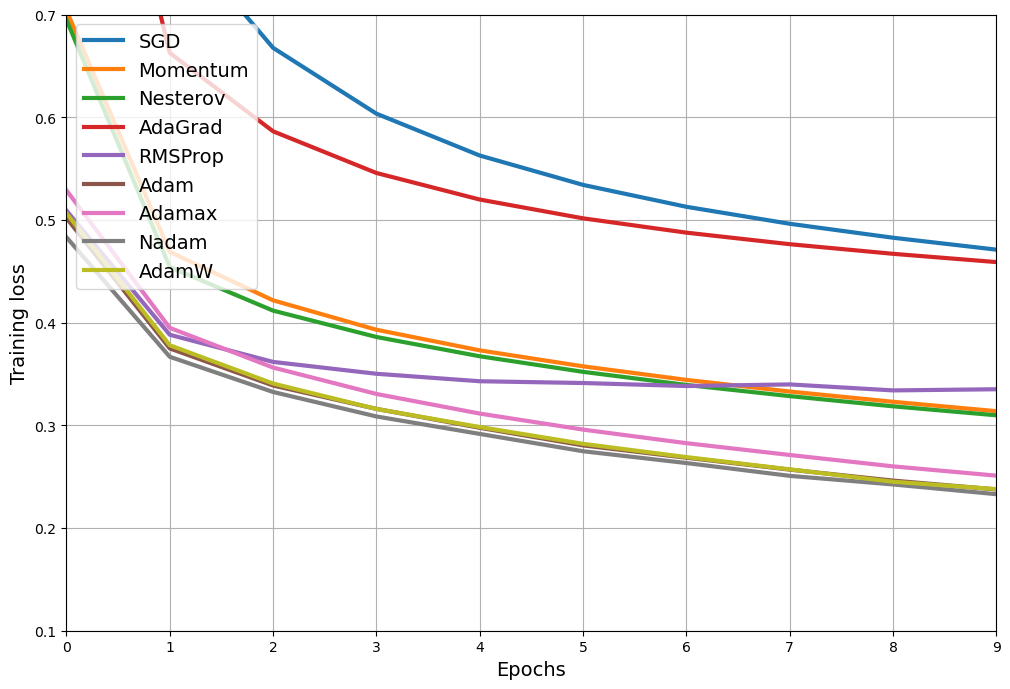

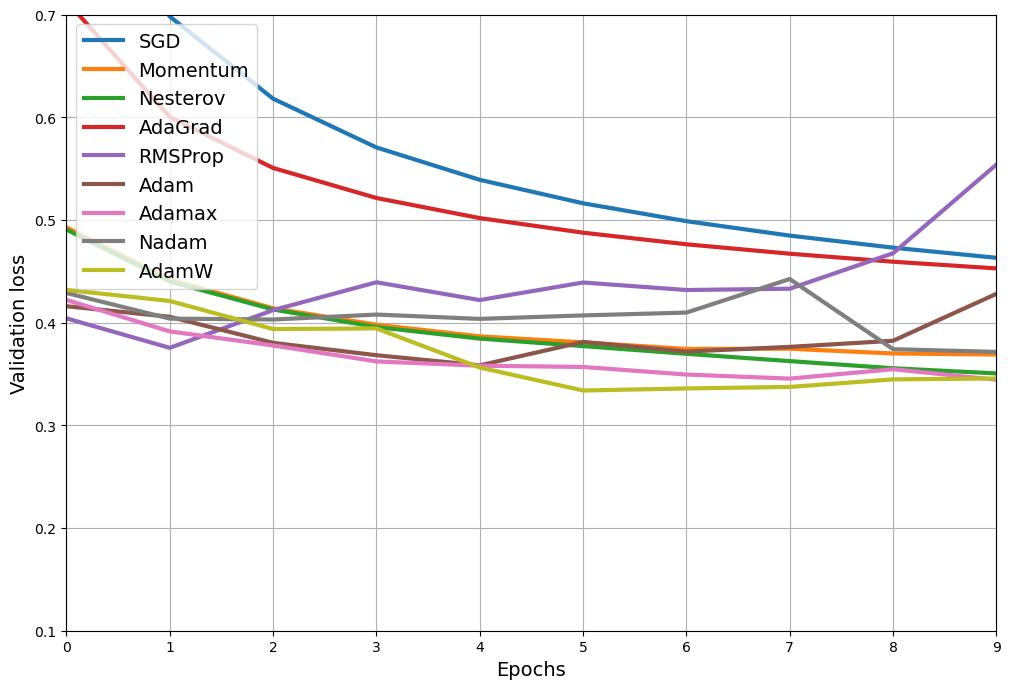

In [67]:
# extra code – visualize the learning curves of all the optimizers

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
                                  history_adamax, history_nadam, history_adamw),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0.1, 0.7])
    plt.show()

## Conclusion: Faster Optimizers

In this section, we explored a range of optimization algorithms designed to accelerate training and improve convergence in deep neural networks. Starting with basic SGD and progressing to adaptive methods like Adam and its variants, we saw how each optimizer balances speed, stability, and generalization.

Key takeaways:
- **Adaptive optimizers** (e.g., Adam, RMSProp) often converge faster initially, making them ideal for prototyping and quick iterations.
- **Momentum-based methods** (e.g., SGD with momentum, Nesterov) typically yield better final generalization, especially with tuned learning rate schedules.
- **AdamW** stands out for its decoupled weight decay, providing robust regularization without interfering with adaptive learning rates.
- The learning curves demonstrate that while Adam and Nadam achieve low loss quickly, momentum-based optimizers like Nesterov maintain steady improvement and lower validation loss over time.

For practical use, begin with Adam for experimentation, then switch to SGD with momentum for production models. Always perform hyperparameter tuning (e.g., learning rate sweeps) and monitor both training and validation metrics to avoid overfitting. Gradient clipping can further stabilize training in unstable scenarios.

This concludes our dive into faster optimizers—next, we'll tackle learning rate scheduling and other advanced training techniques!

---

## Learning Rate Scheduling
Learning-rate (LR) scheduling controls how the step size changes during training — a small, well-chosen schedule often speeds convergence and improves final generalization more than many other hyperparameter tweaks.

Practical overview
- Why: start large to make fast progress, then reduce LR to converge to a better minimum and improve generalization.  
- Common schedules:
    - Step decay — drop LR by a factor at fixed epochs (simple, robust).  
    - Exponential decay — smooth multiplicative decay.  
    - Cosine annealing (with/without restarts) — smooth decay that often yields better final results.  
    - One‑cycle / cyclical LR — helps escape sharp minima and speeds training.  
    - Warmup — ramp LR up for a few epochs/steps (essential for large‑batch training).  
    - ReduceLROnPlateau — lower LR when a monitored metric stops improving.
- Keras tools: `tf.keras.optimizers.schedules.*`, `tf.keras.callbacks.LearningRateScheduler`, `tf.keras.callbacks.ReduceLROnPlateau`.
- Recipe:
    - Do a short LR sweep to find a good max LR.  
    - Prototype with Adam (lr ≈ 1e‑3); for best final results switch to SGD+momentum (lr ≈ 0.01–0.1) and use a decay (cosine or one‑cycle).  
    - Use 5–10% of total steps for warmup when training with large batches.  
    - Monitor validation metrics and save the best weights (early stopping + LR reduction).
- Typical defaults to try: Adam lr=1e‑3, SGD+momentum lr=0.01 (scale with batch size), final LR floor ≈ 1e‑6.

The cells that follow show concrete Keras examples and recipes (LR schedules, callbacks, and a one‑cycle implementation).

### Power Scheduling

Power scheduling decays the learning rate using a polynomial function, where the learning rate decreases as training progresses. The general formula is:
```python
learning_rate = initial_learning_rate / (1 + decay_rate * step / decay_steps)**power
```
where Keras uses `power = 1`.

**Note**: Optimizers used to have a `decay` argument for this, but it was deprecated. You must use the schedulers in `tf.keras.optimizers.schedules` instead.

In [68]:
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1.0,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

The `InverseTimeDecay` scheduler uses `learning_rate = initial_learning_rate / (1 + decay_rate * step / decay_steps)`. If you set `staircase=True`, then it replaces `step / decay_step` with `floor(step / decay_step)`.

In [69]:
history_power_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7632 - loss: 0.6878 - val_accuracy: 0.8306 - val_loss: 0.4854
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8351 - loss: 0.4688 - val_accuracy: 0.8388 - val_loss: 0.4407
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8500 - loss: 0.4232 - val_accuracy: 0.8464 - val_loss: 0.4190
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8587 - loss: 0.3971 - val_accuracy: 0.8540 - val_loss: 0.4029
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8646 - loss: 0.3793 - val_accuracy: 0.8584 - val_loss: 0.3916
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8699 - loss: 0.3661 - val_accuracy: 0.8608 - val_loss: 0.3837
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8732 - loss: 0.3556 - val_accuracy: 0.8630 - val_loss: 0.3755
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8767 - loss: 0.3468 - 

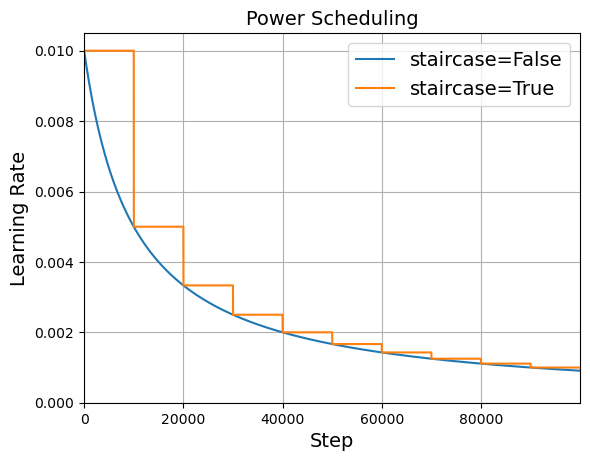

In [70]:
# extra code – this cell plots power scheduling with staircase=True or False

initial_learning_rate = 0.01
decay_rate = 1.0
decay_steps = 10_000

steps = np.arange(100_000)
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### Exponential Scheduling

```python
learning_rate = initial_learning_rate * decay_rate ** (step / decay_steps)
```

In [71]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [72]:
history_exponential_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7617 - loss: 0.6918 - val_accuracy: 0.8216 - val_loss: 0.4952
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8313 - loss: 0.4752 - val_accuracy: 0.8336 - val_loss: 0.4533
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8473 - loss: 0.4299 - val_accuracy: 0.8400 - val_loss: 0.4313
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8555 - loss: 0.4050 - val_accuracy: 0.8480 - val_loss: 0.4152
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8613 - loss: 0.3886 - val_accuracy: 0.8520 - val_loss: 0.4039
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8661 - loss: 0.3770 - val_accuracy: 0.8554 - val_loss: 0.3946
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8693 - loss: 0.3680 - val_accuracy: 0.8572 - val_loss: 0.3862
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8719 - loss: 0.3611 - 

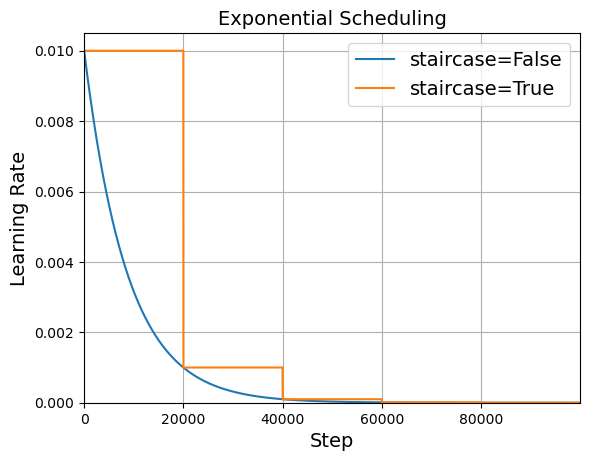

In [73]:
# extra code – this cell plots exponential scheduling

initial_learning_rate = 0.01
decay_rate = 0.1
decay_steps = 20_000

steps = np.arange(100_000)
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

Keras also provides a `LearningRateScheduler` callback class that lets you define your own scheduling function. Let's see how you could use it to implement exponential decay. Note that in this case the learning rate only changes at each epoch, not at each step:

In [74]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

In [75]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.01, s=20)

In [76]:
# extra code – build and compile a model for Fashion MNIST

tf.random.set_seed(42)
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [77]:
n_epochs = 20

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7689 - loss: 0.6792 - val_accuracy: 0.8330 - val_loss: 0.4781 - learning_rate: 0.0100
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8377 - loss: 0.4626 - val_accuracy: 0.8404 - val_loss: 0.4426 - learning_rate: 0.0089
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8514 - loss: 0.4187 - val_accuracy: 0.8498 - val_loss: 0.4205 - learning_rate: 0.0079
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8600 - loss: 0.3936 - val_accuracy: 0.8544 - val_loss: 0.4057 - learning_rate: 0.0071
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8660 - loss: 0.3756 - val_accuracy: 0.8582 - val_loss: 0.3920 - learning_rate: 0.0063
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8711 - loss: 0.3618 - val_accuracy: 0.8604 - val_loss: 0.3854 - learning_rate: 0.0056
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8749 - l

Alternatively, the schedule function can take the current learning rate as a second argument:

In [78]:
def exponential_decay_fn(epoch, lr):
    return lr * 0.1 ** (1 / 20)

**Extra material**: if you want to use a custom scheduling function that updates the learning rate at each iteration rather than at each epoch, you can write your own callback class like this:

In [79]:
K = tf.keras.backend

class ExponentialDecay(tf.keras.callbacks.Callback):
    def __init__(self, n_steps=40_000):
        super().__init__()
        self.n_steps = n_steps

    def on_batch_begin(self, batch, logs=None):
        # Note: the `batch` argument is reset at each epoch
        lr = self.model.optimizer.learning_rate.numpy()
        new_learning_rate = lr * 0.1 ** (1 / self.n_steps)
        self.model.optimizer.learning_rate = new_learning_rate

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = self.model.optimizer.learning_rate.numpy()

In [80]:
lr0 = 0.01
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [81]:
import math

batch_size = 32
n_steps = n_epochs * math.ceil(len(X_train) / batch_size)
exp_decay = ExponentialDecay(n_steps)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[exp_decay])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7583 - loss: 0.6926 - val_accuracy: 0.8282 - val_loss: 0.4967 - lr: 0.0089
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8317 - loss: 0.4753 - val_accuracy: 0.8330 - val_loss: 0.4568 - lr: 0.0079
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8479 - loss: 0.4305 - val_accuracy: 0.8408 - val_loss: 0.4341 - lr: 0.0071
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8567 - loss: 0.4040 - val_accuracy: 0.8450 - val_loss: 0.4165 - lr: 0.0063
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8633 - loss: 0.3859 - val_accuracy: 0.8502 - val_loss: 0.4045 - lr: 0.0056
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8675 - loss: 0.3724 - val_accuracy: 0.8526 - val_loss: 0.3948 - lr: 0.0050
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8711 - loss: 0.3618 - val_accuracy: 0.8560 - val_loss: 0.3873 - lr: 0.0045

### Piecewise Constant Scheduling

In [82]:
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[50_000, 80_000],
    values=[0.01, 0.005, 0.001]
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In [83]:
history_piecewise_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7562 - loss: 0.7202 - val_accuracy: 0.8312 - val_loss: 0.4913
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8333 - loss: 0.4774 - val_accuracy: 0.8398 - val_loss: 0.4439
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8491 - loss: 0.4295 - val_accuracy: 0.8446 - val_loss: 0.4196
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8595 - loss: 0.4000 - val_accuracy: 0.8518 - val_loss: 0.4017
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8667 - loss: 0.3786 - val_accuracy: 0.8574 - val_loss: 0.3915
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8717 - loss: 0.3615 - val_accuracy: 0.8592 - val_loss: 0.3845
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8758 - loss: 0.3471 - val_accuracy: 0.8610 - val_loss: 0.3800
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8799 - loss: 0.3346 - 

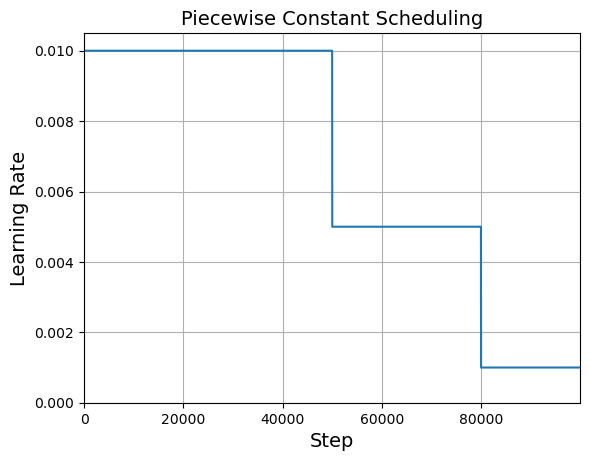

In [84]:
# extra code – this cell plots piecewise constant scheduling

boundaries = [50_000, 80_000]
values = [0.01, 0.005, 0.001]

steps = np.arange(100_000)

lrs = np.full(len(steps), values[0])
for boundary, value in zip(boundaries, values[1:]):
    lrs[boundary:] = value

plt.plot(steps, lrs, "-")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Piecewise Constant Scheduling", fontsize=14)
plt.grid(True)
plt.show()

Just like we did with exponential scheduling, we could also implement piecewise constant scheduling manually:

In [85]:
def piecewise_constant_fn(epoch):
    if epoch < 5:
        return 0.01
    elif epoch < 15:
        return 0.005
    else:
        return 0.001

In [86]:
# extra code – this cell demonstrates a more general way to define
#              piecewise constant scheduling.

def piecewise_constant(boundaries, values):
    boundaries = np.array([0] + boundaries)
    values = np.array(values)
    def piecewise_constant_fn(epoch):
        return values[(boundaries > epoch).argmax() - 1]
    return piecewise_constant_fn

piecewise_constant_fn = piecewise_constant([5, 15], [0.01, 0.005, 0.001])

In [87]:
# extra code – use a tf.keras.callbacks.LearningRateScheduler like earlier

n_epochs = 25

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(piecewise_constant_fn)

model = build_model()
optimizer = tf.keras.optimizers.Nadam(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8086 - loss: 0.5407 - val_accuracy: 0.8454 - val_loss: 0.4366 - learning_rate: 0.0100
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8406 - loss: 0.4542 - val_accuracy: 0.8122 - val_loss: 0.5723 - learning_rate: 0.0100
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8485 - loss: 0.4280 - val_accuracy: 0.8438 - val_loss: 0.4243 - learning_rate: 0.0100
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8511 - loss: 0.4231 - val_accuracy: 0.8524 - val_loss: 0.4395 - learning_rate: 0.0100
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8575 - loss: 0.4086 - val_accuracy: 0.8328 - val_loss: 0.4605 - learning_rate: 0.0100
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8708 - loss: 0.3605 - val_accuracy: 0.8582 - val_loss: 0.3933 - learning_rate: 0.0050
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8746 - l

We've looked at `InverseTimeDecay`, `ExponentialDecay`, and `PiecewiseConstantDecay`. A few more schedulers are available in `tf.keras.optimizers.schedules`, here is the full list:

In [88]:
for name in sorted(dir(tf.keras.optimizers.schedules)):
    if name[0] == name[0].lower():  # must start with capital letter
        continue
    scheduler_class = getattr(tf.keras.optimizers.schedules, name)
    print(f"• {name} – {scheduler_class.__doc__.splitlines()[0]}")

• CosineDecay – A `LearningRateSchedule` that uses a cosine decay with optional warmup.
• CosineDecayRestarts – A `LearningRateSchedule` that uses a cosine decay schedule with restarts.
• ExponentialDecay – A `LearningRateSchedule` that uses an exponential decay schedule.
• InverseTimeDecay – A `LearningRateSchedule` that uses an inverse time decay schedule.
• LearningRateSchedule – The learning rate schedule base class.
• PiecewiseConstantDecay – A `LearningRateSchedule` that uses a piecewise constant decay schedule.
• PolynomialDecay – A `LearningRateSchedule` that uses a polynomial decay schedule.


### Performance Scheduling

Performance scheduling adjusts the learning rate based on the model's performance metrics, such as validation loss or accuracy. Unlike time-based schedules, it dynamically reduces the learning rate when a monitored metric stops improving, helping to fine-tune convergence and prevent overfitting. This is particularly useful for adaptive training where the optimal learning rate changes over time.

In [89]:
# extra code – build and compile the model

model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])


In Keras, this is implemented using the `ReduceLROnPlateau` callback, which monitors a metric (e.g., validation loss) and reduces the learning rate by a factor when the metric hasn't improved for a specified number of epochs (patience). It can also stop training early if desired.

Key parameters:
- `monitor`: The metric to monitor (e.g., 'val_loss').
- `factor`: Factor by which the learning rate will be reduced (e.g., 0.5).
- `patience`: Number of epochs with no improvement after which learning rate will be reduced.
- `min_lr`: Minimum learning rate.
- `mode`: 'auto', 'min', or 'max' depending on whether the metric should be minimized or maximized.

This approach is robust for datasets where the optimal learning rate isn't known in advance and can lead to better generalization by allowing the model to settle into a minimum more gradually. Always combine with early stopping for efficiency.



In [90]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7652 - loss: 0.6827 - val_accuracy: 0.8248 - val_loss: 0.4855 - learning_rate: 0.0100
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8361 - loss: 0.4629 - val_accuracy: 0.8284 - val_loss: 0.4482 - learning_rate: 0.0100
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8512 - loss: 0.4172 - val_accuracy: 0.8414 - val_loss: 0.4186 - learning_rate: 0.0100
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8604 - loss: 0.3892 - val_accuracy: 0.8570 - val_loss: 0.3978 - learning_rate: 0.0100
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8677 - loss: 0.3688 - val_accuracy: 0.8608 - val_loss: 0.3810 - learning_rate: 0.0100
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8731 - loss: 0.3528 - val_accuracy: 0.8662 - val_loss: 0.3699 - learning_rate: 0.0100
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8775 - l

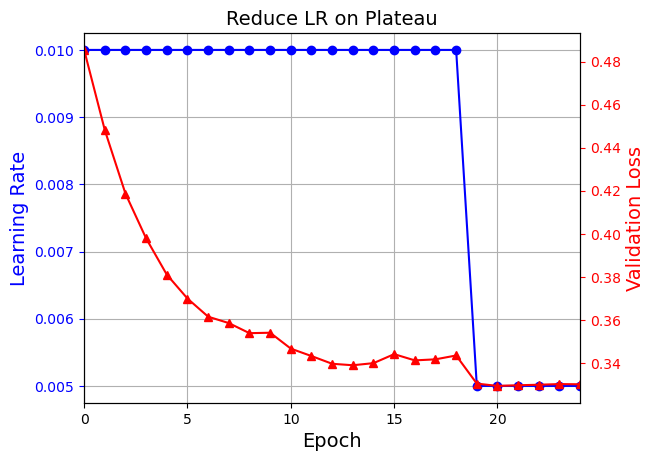

In [91]:
# extra code – this cell plots performance scheduling

plt.plot(history.epoch, history.history["learning_rate"], "bo-")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate", color='b')
plt.tick_params('y', colors='b')
plt.gca().set_xlim(0, n_epochs - 1)
plt.grid(True)

ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")
ax2.set_ylabel('Validation Loss', color='r')
ax2.tick_params('y', colors='r')

plt.title("Reduce LR on Plateau", fontsize=14)
plt.show()

### 1Cycle scheduling

The `ExponentialLearningRate` custom callback updates the learning rate during training, at the end of each batch. It multiplies it by a constant `factor`. It also saves the learning rate and loss at each batch. Since `logs["loss"]` is actually the mean loss since the start of the epoch, and we want to save the batch loss instead, we must compute the mean times the number of batches since the beginning of the epoch to get the total loss so far, then we subtract the total loss at the previous batch to get the current batch's loss.

In [92]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_epoch_begin(self, epoch, logs=None):
        self.sum_of_epoch_losses = 0

    def on_batch_end(self, batch, logs=None):
        mean_epoch_loss = logs["loss"]  # the epoch's mean loss so far 
        new_sum_of_epoch_losses = mean_epoch_loss * (batch + 1)
        batch_loss = new_sum_of_epoch_losses - self.sum_of_epoch_losses
        self.sum_of_epoch_losses = new_sum_of_epoch_losses
        lr = self.model.optimizer.learning_rate.numpy()
        self.rates.append(lr)
        self.losses.append(batch_loss)
        self.model.optimizer.learning_rate = lr * self.factor

The `find_learning_rate()` function trains the model using the `ExponentialLearningRate` callback, and it returns the learning rates and corresponding batch losses. At the end, it restores the model and its optimizer to their initial state.

In [93]:
def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=1e-4,
                       max_rate=1):
    init_weights = model.get_weights()
    iterations = math.ceil(len(X) / batch_size) * epochs
    factor = (max_rate / min_rate) ** (1 / iterations)
    init_lr = K.get_value(model.optimizer.learning_rate)
    model.optimizer.learning_rate = min_rate
    exp_lr = ExponentialLearningRate(factor)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size,
                        callbacks=[exp_lr])
    model.optimizer.learning_rate = init_lr
    model.set_weights(init_weights)
    return exp_lr.rates, exp_lr.losses

The `plot_lr_vs_loss()` function plots the learning rates vs the losses. The optimal learning rate to use as the maximum learning rate in 1cycle is near the bottom of the curve.

In [94]:
def plot_lr_vs_loss(rates, losses):
    plt.plot(rates, losses, "b")
    plt.gca().set_xscale('log')
    max_loss = losses[0] + min(losses)
    plt.hlines(min(losses), min(rates), max(rates), color="k")
    plt.axis([min(rates), max(rates), 0, max_loss])
    plt.xlabel("Learning rate")
    plt.ylabel("Loss")
    plt.grid()

Let's build a simple Fashion MNIST model and compile it:

In [95]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

Now let's find the optimal max learning rate for 1cycle:

430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3758 - loss: 1.8584


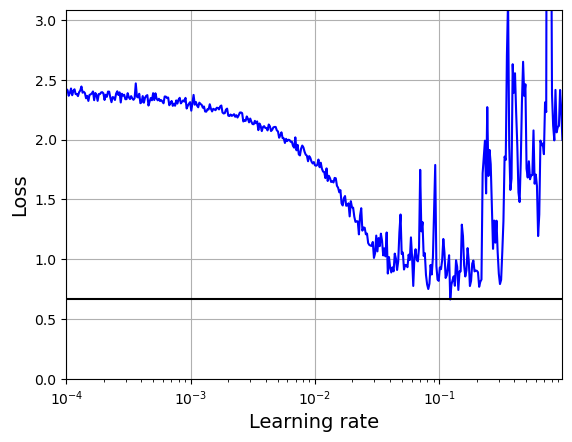

In [96]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

Looks like the max learning rate to use for 1cycle is around 10<sup>–1</sup>.

The `OneCycleScheduler` custom callback updates the learning rate at the beginning of each batch. It applies the logic described in the book: increase the learning rate linearly during about half of training, then reduce it linearly back to the initial learning rate, and lastly reduce it down to close to zero linearly for the very last part of training.

In [97]:
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(self, iterations, max_lr=1e-3, start_lr=None,
                 last_iterations=None, last_lr=None):
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0

    def _interpolate(self, iter1, iter2, lr1, lr2):
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch, logs):
        if self.iteration < self.half_iteration:
            lr = self._interpolate(0, self.half_iteration, self.start_lr,
                                   self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                   self.max_lr, self.start_lr)
        else:
            lr = self._interpolate(2 * self.half_iteration, self.iterations,
                                   self.start_lr, self.last_lr)
        self.iteration += 1
        self.model.optimizer.learning_rate = lr

Let's build and compile a simple Fashion MNIST model, then train it using the `OneCycleScheduler` callback:

In [98]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])
n_epochs = 25
onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs,
                             max_lr=0.1)
history = model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid, y_valid),
                    callbacks=[onecycle])

Epoch 1/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6925 - loss: 0.9231 - val_accuracy: 0.8056 - val_loss: 0.5812
Epoch 2/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8023 - loss: 0.5624 - val_accuracy: 0.8208 - val_loss: 0.5053
Epoch 3/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8259 - loss: 0.4925 - val_accuracy: 0.8116 - val_loss: 0.5075
Epoch 4/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8399 - loss: 0.4531 - val_accuracy: 0.8034 - val_loss: 0.5262
Epoch 5/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8503 - loss: 0.4232 - val_accuracy: 0.7996 - val_loss: 0.5389
Epoch 6/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8576 - loss: 0.3991 - val_accuracy: 0.7990 - val_loss: 0.5331
Epoch 7/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8627 - loss: 0.3801 - val_accuracy: 0.8104 - val_loss: 0.5144
Epoch 8/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8680 - loss: 0.3639 - val_accuracy: 0.

---

# Avoiding Overfitting Through Regularization

Regularization reduces a model's tendency to memorize the training set so it generalizes better to new data. This section summarizes the most effective techniques, when to use them, and a compact troubleshooting recipe you can apply to any model.

Why regularize?
- Overfitting arises when model capacity, training time, or label/noise characteristics let the model fit idiosyncrasies of the training set rather than the underlying signal.
- Regularization trades some training accuracy for lower generalization error.

Common techniques (brief)
- Data: more labeled data, smarter data augmentation (strongest and often cheapest payoff).
- Optimization/early stopping: shorter training / monitor validation loss, ReduceLROnPlateau, weight‑averaging.
- Weight regularization: L2 (weight decay), L1 (sparsity).
- Architectural: dropout, batch normalization, smaller networks.
- Label/target: label smoothing, mixup, noise injection.
- Ensembling and distillation: expensive but very effective for final models.
- Pruning and quantization: for deployment (reduces capacity / overfitting in some cases).

Practical recipe
1. Verify overfitting with learning curves (train vs val).  
2. Fix data issues first (more data, better augmentation, cleaner labels).  
3. Add/strengthen weight decay (start 1e‑4 → 1e‑2) and/or dropout (0.1–0.5) and retune LR.  
4. Use early stopping + save best weights; try ReduceLROnPlateau.  
5. If needed, simplify the model or use ensembling/distillation for production.  
6. Run small ablations (one change at a time) and multiple seeds.

What follows
- Concrete Keras examples: L2 weight decay, dropout, label smoothing, augmentation pipelines, and learning‑curve diagnostics — plus recommended hyperparameter ranges and ablation experiments to quantify impact.

## $\ell_1$ and $\ell_2$ regularization

This code creates a dense layer with 100 neurons using the ReLU activation function and L2 weight regularization (weight decay). The `kernel_regularizer=tf.keras.regularizers.l2(0.01)` argument applies L2 regularization with a factor of 0.01 to the layer's weights, helping to prevent overfitting by penalizing large weights during training.

In [99]:
layer = tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal",
                              kernel_regularizer=tf.keras.regularizers.l2(0.01))

Or use `l1(0.1)` for ℓ<sub>1</sub> regularization with a factor of 0.1, or `l1_l2(0.1, 0.01)` for both ℓ<sub>1</sub> and ℓ<sub>2</sub> regularization, with factors 0.1 and 0.01 respectively.

In [100]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [101]:
from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax")
])

In [102]:
# extra code – compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7737 - loss: 3.1318 - val_accuracy: 0.8248 - val_loss: 1.8654
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8135 - loss: 1.4314 - val_accuracy: 0.8220 - val_loss: 1.1217


---
## Dropout

Dropout randomly zeroes activations during training to prevent co‑adaptation of neurons — effectively performing model-averaging and reducing overfitting.

- When to use: large fully‑connected layers or when validation gap indicates overfitting; less useful if you already have strong augmentation, large datasets, or heavy weight decay.
- Typical rates: dense layers 0.3–0.5; convolutional layers 0.1–0.3; start small and sweep.
- Placement: usually after the activation of a layer (e.g., Dense→Activation→Dropout). Avoid pairing aggressively with BatchNorm (BatchNorm often reduces the need for dropout).
- Training vs inference: dropout is active only during training; Keras uses inverted dropout so no extra scaling is needed at test time.
- Tuning tips: tune dropout together with learning rate and weight decay; more dropout often requires longer training or a slightly higher LR.
- Debugging: if training accuracy collapses, lower the rate or increase model capacity; if validation is noisy, try larger batch size, stronger augmentation, or ReduceLROnPlateau.
- Advanced: use Monte‑Carlo (MC) Dropout for uncertainty estimates by keeping dropout active at inference (run multiple stochastic forward passes and average).

Example (Keras):
```python
tf.keras.layers.Dense(100, activation="relu"),
tf.keras.layers.Dropout(0.5)
```

Quick MC‑Dropout inference pattern:
```python
# run `model(x, training=True)` several times and compute mean/std of outputs
```

In [103]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [104]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [105]:
# extra code – compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7511 - loss: 0.6787 - val_accuracy: 0.8298 - val_loss: 0.4513
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8121 - loss: 0.5178 - val_accuracy: 0.8440 - val_loss: 0.4141
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8254 - loss: 0.4772 - val_accuracy: 0.8512 - val_loss: 0.3939
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8345 - loss: 0.4502 - val_accuracy: 0.8610 - val_loss: 0.3813
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8411 - loss: 0.4332 - val_accuracy: 0.8532 - val_loss: 0.3777
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8436 - loss: 0.4230 - val_accuracy: 0.8576 - val_loss: 0.3636
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8487 - loss: 0.4106 - val_accuracy: 0.8640 - val_loss: 0.3685
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8531 - loss: 0.4017 - 

The training accuracy looks like it's lower than the validation accuracy, but that's just because dropout is only active during training. If we evaluate the model on the training set after training (i.e., with dropout turned off), we get the "real" training accuracy, which is very slightly higher than the validation accuracy and the test accuracy:

In [106]:
model.evaluate(X_train, y_train)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8810 - loss: 0.3127


[0.31272581219673157, 0.8810363411903381]

In [107]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8571 - loss: 0.3739


[0.37386199831962585, 0.8571000099182129]

**Note**: make sure to use `AlphaDropout` instead of `Dropout` if you want to build a self-normalizing neural net using SELU.

## MC Dropout
MC Dropout (Monte Carlo Dropout) is a technique used to estimate uncertainty in neural network predictions by applying dropout during both training and inference. This allows the model to generate multiple stochastic forward passes, providing a distribution of outputs that can be analyzed for uncertainty quantification.

To implement MC Dropout in Keras, you can create a custom dropout layer that remains active during inference. Here's an example of how to do this:

In [108]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [109]:
y_probas = np.stack([model(X_test, training=True)
                     for sample in range(100)])
y_proba = y_probas.mean(axis=0)

In [110]:
model.predict(X_test[:1]).round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.045, 0.   , 0.13 , 0.   ,
        0.825]], dtype=float32)

In [111]:
y_proba[0].round(3)

array([0.001, 0.   , 0.   , 0.   , 0.001, 0.158, 0.001, 0.152, 0.002,
       0.684], dtype=float32)

In [112]:
y_std = y_probas.std(axis=0)
y_std[0].round(3)

array([0.003, 0.002, 0.002, 0.001, 0.003, 0.202, 0.005, 0.154, 0.015,
       0.236], dtype=float32)

In [113]:
y_pred = y_proba.argmax(axis=1)
accuracy = (y_pred == y_test).sum() / len(y_test)
accuracy

0.8568

In [114]:
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

In [115]:
# extra code – shows how to convert Dropout to MCDropout in a Sequential model
Dropout = tf.keras.layers.Dropout
mc_model = tf.keras.Sequential([
    MCDropout(layer.rate) if isinstance(layer, Dropout) else layer
    for layer in model.layers
])
mc_model.set_weights(model.get_weights())

In [116]:
mc_model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout (MCDropout)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_1 (MCDropout)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_2 (MCDropout)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

Now we can use the model with MC Dropout:

In [117]:
# extra code – shows that the model works without retraining
tf.random.set_seed(42)
np.mean([mc_model.predict(X_test[:1])
         for sample in range(100)], axis=0).round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.13, 0.  , 0.16, 0.  , 0.71]],
      dtype=float32)

---
## Max norm
Max norm regularization constrains the maximum norm of the weights in each layer to a specified value, preventing them from growing too large and helping to reduce overfitting. This technique can improve generalization by keeping the model's capacity in check.

In [118]:
dense = tf.keras.layers.Dense(
    100, activation="relu", kernel_initializer="he_normal",
    kernel_constraint=tf.keras.constraints.max_norm(1.))

In [119]:
# extra code – shows how to apply max norm to every hidden layer in a model

MaxNormDense = partial(tf.keras.layers.Dense,
                       activation="relu", kernel_initializer="he_normal",
                       kernel_constraint=tf.keras.constraints.max_norm(1.))

tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    MaxNormDense(100),
    MaxNormDense(100),
    tf.keras.layers.Dense(10, activation="softmax")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10


c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8015 - loss: 0.5539 - val_accuracy: 0.8294 - val_loss: 0.4500
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8496 - loss: 0.4121 - val_accuracy: 0.8438 - val_loss: 0.4080
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8609 - loss: 0.3785 - val_accuracy: 0.8590 - val_loss: 0.3906
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8672 - loss: 0.3590 - val_accuracy: 0.8568 - val_loss: 0.3846
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8712 - loss: 0.3462 - val_accuracy: 0.8576 - val_loss: 0.3960
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8726 - loss: 0.3380 - val_accuracy: 0.8480 - val_loss: 0.4090
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8758 - loss: 0.3318 - val_accuracy: 0.8608 - val_loss: 0.3861
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8783 - loss: 0.3280 - val_accurac

---

# Exercises

## 1. to 7.

1. Glorot initialization and He initialization were designed to make the output standard deviation as close as possible to the input standard deviation, at least at the beginning of training. This reduces the vanishing/exploding gradients problem.
2. No, all weights should be sampled independently; they should not all have the same initial value. One important goal of sampling weights randomly is to break symmetry: if all the weights have the same initial value, even if that value is not zero, then symmetry is not broken (i.e., all neurons in a given layer are equivalent), and backpropagation will be unable to break it. Concretely, this means that all the neurons in any given layer will always have the same weights. It's like having just one neuron per layer, and much slower. It is virtually impossible for such a configuration to converge to a good solution.
3. It is perfectly fine to initialize the bias terms to zero. Some people like to initialize them just like weights, and that's OK too; it does not make much difference.
4. ReLU is usually a good default for the hidden layers, as it is fast and yields good results. Its ability to output precisely zero can also be useful in some cases (e.g., see Chapter 17). Moreover, it can sometimes benefit from optimized implementations as well as from hardware acceleration. The leaky ReLU variants of ReLU can improve the model's quality without hindering its speed too much compared to ReLU. For large neural nets and more complex problems, GLU, Swish and Mish can give you a slightly higher quality model, but they have a computational cost. The hyperbolic tangent (tanh) can be useful in the output layer if you need to output a number in a fixed range (by default between –1 and 1), but nowadays it is not used much in hidden layers, except in recurrent nets. The sigmoid activation function is also useful in the output layer when you need to estimate a probability (e.g., for binary classification), but it is rarely used in hidden layers (there are exceptions—for example, for the coding layer of variational autoencoders; see Chapter 17). The softplus activation function is useful in the output layer when you need to ensure that the output will always be positive. The softmax activation function is useful in the output layer to estimate probabilities for mutually exclusive classes, but it is rarely (if ever) used in hidden layers.
5. If you set the `momentum` hyperparameter too close to 1 (e.g., 0.99999) when using an `SGD` optimizer, then the algorithm will likely pick up a lot of speed, hopefully moving roughly toward the global minimum, but its momentum will carry it right past the minimum. Then it will slow down and come back, accelerate again, overshoot again, and so on. It may oscillate this way many times before converging, so overall it will take much longer to converge than with a smaller `momentum` value.
6. One way to produce a sparse model (i.e., with most weights equal to zero) is to train the model normally, then zero out tiny weights. For more sparsity, you can apply ℓ<sub>1</sub> regularization during training, which pushes the optimizer toward sparsity. A third option is to use the TensorFlow Model Optimization Toolkit.
7. Yes, dropout does slow down training, in general roughly by a factor of two. However, it has no impact on inference speed since it is only turned on during training. MC Dropout is exactly like dropout during training, but it is still active during inference, so each inference is slowed down slightly. More importantly, when using MC Dropout you generally want to run inference 10 times or more to get better predictions. This means that making predictions is slowed down by a factor of 10 or more.

---

## 8. Deep Learning on CIFAR10

In this exercise, you will build and train a deep neural network on the CIFAR10 dataset (60,000 32×32 color images in 10 classes) using TensorFlow/Keras. You will start with a baseline model and progressively apply techniques covered in this chapter to improve generalization and prevent overfitting, such as data augmentation, weight regularization (L2, dropout, max norm), and advanced optimizers and learning rate scheduling. The workflow includes loading and preprocessing the data, defining and compiling the model, training with callbacks (e.g., early stopping, learning rate schedulers), and evaluating performance on the test set. Experiment with hyperparameter tuning and regularization strategies to achieve strong test accuracy, aiming for at least 80%.

### a.
*Exercise: Build a DNN with 20 hidden layers of 100 neurons each (that's too many, but it's the point of this exercise). Use He initialization and the Swish activation function.*

In [117]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    activation="swish",
                                    kernel_initializer="he_normal"))

### b.
*Exercise: Using Nadam optimization and early stopping, train the network on the CIFAR10 dataset. You can load it with `tf.keras.datasets.cifar10.load_data()`. The dataset is composed of 60,000 32 × 32–pixel color images (50,000 for training, 10,000 for testing) with 10 classes, so you'll need a softmax output layer with 10 neurons. Remember to search for the right learning rate each time you change the model's architecture or hyperparameters.*

Let's add the output layer to the model:

In [118]:
model.add(tf.keras.layers.Dense(10, activation="softmax"))

Let's use a Nadam optimizer with a learning rate of 5e-5. I tried learning rates 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3 and 1e-2, and I compared their learning curves for 10 epochs each (using the TensorBoard callback, below). The learning rates 3e-5 and 1e-4 were pretty good, so I tried 5e-5, which turned out to be slightly better.

In [119]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-5)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

Let's load the CIFAR10 dataset. We also want to use early stopping, so we need a validation set. Let's use the first 5,000 images of the original training set as the validation set:

In [120]:
cifar10 = tf.keras.datasets.cifar10.load_data()
(X_train_full, y_train_full), (X_test, y_test) = cifar10

X_train = X_train_full[5000:]
y_train = y_train_full[5000:]
X_valid = X_train_full[:5000]
y_valid = y_train_full[:5000]

Now we can create the callbacks we need and train the model:

In [121]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_cifar10_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

In [122]:
%load_ext tensorboard
%tensorboard --logdir=./my_cifar10_logs

In [123]:
model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

Epoch 1/100
1407/1407 [==============================] - 17s 10ms/step - loss: 4.0462 - accuracy: 0.1597 - val_loss: 2.1441 - val_accuracy: 0.2036
Epoch 2/100
1407/1407 [==============================] - 12s 9ms/step - loss: 2.0667 - accuracy: 0.2320 - val_loss: 2.0134 - val_accuracy: 0.2472
Epoch 3/100
1407/1407 [==============================] - 14s 10ms/step - loss: 1.9472 - accuracy: 0.2819 - val_loss: 1.9427 - val_accuracy: 0.2796
Epoch 4/100
1407/1407 [==============================] - 14s 10ms/step - loss: 1.8637 - accuracy: 0.3182 - val_loss: 1.8934 - val_accuracy: 0.3222
Epoch 5/100
1407/1407 [==============================] - 14s 10ms/step - loss: 1.7974 - accuracy: 0.3465 - val_loss: 1.8389 - val_accuracy: 0.3284
Epoch 6/100
1407/1407 [==============================] - 9s 7ms/step - loss: 1.7446 - accuracy: 0.3664 - val_loss: 2.0006 - val_accuracy: 0.3030
Epoch 7/100
1407/1407 [==============================] - 12s 8ms/step - loss: 1.6974 - accuracy: 0.3852 - val_loss: 1.707

In [124]:
model.evaluate(X_valid, y_valid)

157/157 [==============================] - 0s 2ms/step - loss: 1.5062 - accuracy: 0.4676


[1.5061508417129517, 0.4675999879837036]

The model with the lowest validation loss gets about 46.8% accuracy on the validation set. It took 29 epochs to reach the lowest validation loss, with roughly 10 seconds per epoch on my laptop (without a GPU). Let's see if we can improve the model using Batch Normalization.

### c.
*Exercise: Now try adding Batch Normalization and compare the learning curves: Is it converging faster than before? Does it produce a better model? How does it affect training speed?*

The code below is very similar to the code above, with a few changes:

* I added a BN layer after every Dense layer (before the activation function), except for the output layer.
* I changed the learning rate to 5e-4. I experimented with 1e-5, 3e-5, 5e-5, 1e-4, 3e-4, 5e-4, 1e-3 and 3e-3, and I chose the one with the best validation performance after 20 epochs.
* I renamed the run directories to run_bn_* and the model file name to `my_cifar10_bn_model`.

In [125]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100, kernel_initializer="he_normal"))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation("swish"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_cifar10_bn_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_bn_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid, y_valid)

Epoch 1/100
1407/1407 [==============================] - 32s 18ms/step - loss: 2.0374 - accuracy: 0.2525 - val_loss: 1.8766 - val_accuracy: 0.3154
Epoch 2/100
1407/1407 [==============================] - 17s 12ms/step - loss: 1.7874 - accuracy: 0.3542 - val_loss: 1.8784 - val_accuracy: 0.3268
Epoch 3/100
1407/1407 [==============================] - 20s 15ms/step - loss: 1.6806 - accuracy: 0.3969 - val_loss: 1.9764 - val_accuracy: 0.3252
Epoch 4/100
1407/1407 [==============================] - 24s 17ms/step - loss: 1.6112 - accuracy: 0.4228 - val_loss: 1.7087 - val_accuracy: 0.3750
Epoch 5/100
1407/1407 [==============================] - 21s 15ms/step - loss: 1.5521 - accuracy: 0.4476 - val_loss: 1.6272 - val_accuracy: 0.4176
Epoch 6/100
1407/1407 [==============================] - 23s 16ms/step - loss: 1.5030 - accuracy: 0.4660 - val_loss: 1.5401 - val_accuracy: 0.4452
Epoch 7/100
1407/1407 [==============================] - 15s 11ms/step - loss: 1.4559 - accuracy: 0.4812 - val_loss: 1

[1.4236289262771606, 0.5073999762535095]

* *Is the model converging faster than before?* Much faster! The previous model took 29 epochs to reach the lowest validation loss, while the new model achieved that same loss in just 12 epochs and continued to make progress until the 17th epoch. The BN layers stabilized training and allowed us to use a much larger learning rate, so convergence was faster.
* *Does BN produce a better model?* Yes! The final model is also much better, with 50.7% validation accuracy instead of 46.7%. It's still not a very good model, but at least it's much better than before (a Convolutional Neural Network would do much better, but that's a different topic, see chapter 14).
* *How does BN affect training speed?* Although the model converged much faster, each epoch took about 15s instead of 10s, because of the extra computations required by the BN layers. But overall the training time (wall time) to reach the best model was shortened by about 10%.

### d.
*Exercise: Try replacing Batch Normalization with SELU, and make the necessary adjustements to ensure the network self-normalizes (i.e., standardize the input features, use LeCun normal initialization, make sure the DNN contains only a sequence of dense layers, etc.).*

In [126]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=7e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_selu_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_selu_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=100,
          validation_data=(X_valid_scaled, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid_scaled, y_valid)

Epoch 1/100
1407/1407 [==============================] - 20s 13ms/step - loss: 1.9385 - accuracy: 0.3046 - val_loss: 1.8175 - val_accuracy: 0.3510
Epoch 2/100
1407/1407 [==============================] - 16s 11ms/step - loss: 1.7241 - accuracy: 0.3869 - val_loss: 1.7677 - val_accuracy: 0.3614
Epoch 3/100
1407/1407 [==============================] - 18s 13ms/step - loss: 1.6272 - accuracy: 0.4263 - val_loss: 1.6878 - val_accuracy: 0.4054
Epoch 4/100
1407/1407 [==============================] - 18s 13ms/step - loss: 1.5643 - accuracy: 0.4492 - val_loss: 1.6589 - val_accuracy: 0.4304
Epoch 5/100
1407/1407 [==============================] - 16s 11ms/step - loss: 1.5080 - accuracy: 0.4712 - val_loss: 1.5651 - val_accuracy: 0.4538
Epoch 6/100
1407/1407 [==============================] - 17s 12ms/step - loss: 1.4613 - accuracy: 0.4872 - val_loss: 1.5305 - val_accuracy: 0.4678
Epoch 7/100
1407/1407 [==============================] - 17s 12ms/step - loss: 1.4174 - accuracy: 0.5077 - val_loss: 1

[1.4607702493667603, 0.5026000142097473]

This model reached the first model's validation loss in just 8 epochs. After 14 epochs, it reached its lowest validation loss, with about 50.3% accuracy, which is better than the original model (46.7%), but not quite as good as the model using batch normalization (50.7%). Each epoch took only 9 seconds. So it's the fastest model to train so far.

### e.
*Exercise: Try regularizing the model with alpha dropout. Then, without retraining your model, see if you can achieve better accuracy using MC Dropout.*

**Warning**: there are now two versions of `AlphaDropout`. One is deprecated and also broken in some recent versions of TF, and unfortunately that's the version in the `tensorflow` library. Luckily, there's a perfectly fine version in the `keras` library (i.e., `keras`, not `tf.keras`). It's neither deprecated nor broken, so let's import and use that one:

In [127]:
import keras.layers

In [128]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_alpha_dropout_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_alpha_dropout_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=100,
          validation_data=(X_valid_scaled, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid_scaled, y_valid)

Epoch 1/100
1407/1407 [==============================] - 18s 11ms/step - loss: 1.8950 - accuracy: 0.3239 - val_loss: 1.7556 - val_accuracy: 0.3812
Epoch 2/100
1407/1407 [==============================] - 16s 11ms/step - loss: 1.6618 - accuracy: 0.4130 - val_loss: 1.6563 - val_accuracy: 0.4114
Epoch 3/100
1407/1407 [==============================] - 16s 11ms/step - loss: 1.5770 - accuracy: 0.4432 - val_loss: 1.6507 - val_accuracy: 0.4232
Epoch 4/100
1407/1407 [==============================] - 15s 10ms/step - loss: 1.5081 - accuracy: 0.4672 - val_loss: 1.5892 - val_accuracy: 0.4566
Epoch 5/100
1407/1407 [==============================] - 14s 10ms/step - loss: 1.4561 - accuracy: 0.4902 - val_loss: 1.5382 - val_accuracy: 0.4696
Epoch 6/100
1407/1407 [==============================] - 16s 11ms/step - loss: 1.4094 - accuracy: 0.5050 - val_loss: 1.5236 - val_accuracy: 0.4818
Epoch 7/100
1407/1407 [==============================] - 14s 10ms/step - loss: 1.3636 - accuracy: 0.5232 - val_loss: 1

[1.4779616594314575, 0.498199999332428]

The model reaches 48.1% accuracy on the validation set. That's worse than without dropout (50.3%). With an extensive hyperparameter search, it might be possible to do better (I tried dropout rates of 5%, 10%, 20% and 40%, and learning rates 1e-4, 3e-4, 5e-4, and 1e-3), but probably not much better in this case.

Let's use MC Dropout now. We will need the `MCAlphaDropout` class we used earlier, so let's just copy it here for convenience:

In [129]:
class MCAlphaDropout(keras.layers.AlphaDropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

Now let's create a new model, identical to the one we just trained (with the same weights), but with `MCAlphaDropout` dropout layers instead of `AlphaDropout` layers:

In [130]:
mc_model = tf.keras.Sequential([
    (
        MCAlphaDropout(layer.rate)
        if isinstance(layer, keras.layers.AlphaDropout)
        else layer
    )
    for layer in model.layers
])

Then let's add a couple utility functions. The first will run the model many times (10 by default) and it will return the mean predicted class probabilities. The second will use these mean probabilities to predict the most likely class for each instance:

In [131]:
def mc_dropout_predict_probas(mc_model, X, n_samples=10):
    Y_probas = [mc_model.predict(X) for sample in range(n_samples)]
    return np.mean(Y_probas, axis=0)

def mc_dropout_predict_classes(mc_model, X, n_samples=10):
    Y_probas = mc_dropout_predict_probas(mc_model, X, n_samples)
    return Y_probas.argmax(axis=1)

Now let's make predictions for all the instances in the validation set, and compute the accuracy:

In [132]:
tf.random.set_seed(42)

y_pred = mc_dropout_predict_classes(mc_model, X_valid_scaled)
accuracy = (y_pred == y_valid[:, 0]).mean()
accuracy

0.4984

We get back to roughly the accuracy of the model without dropout in this case (about 50.3% accuracy).

So the best model we got in this exercise is the Batch Normalization model.

### f.
*Exercise: Retrain your model using 1cycle scheduling and see if it improves training speed and model accuracy.*

In [133]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.SGD()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

352/352 [==============================] - 3s 8ms/step - loss: nan - accuracy: 0.1706


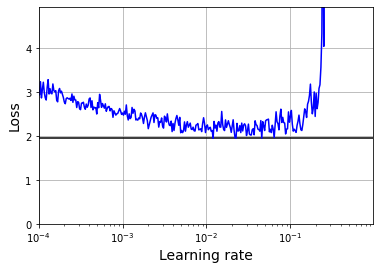

In [134]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train_scaled, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

In [135]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                 kernel_initializer="lecun_normal",
                                 activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.SGD(learning_rate=2e-2)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [136]:
n_epochs = 15
n_iterations = math.ceil(len(X_train_scaled) / batch_size) * n_epochs
onecycle = OneCycleScheduler(n_iterations, max_lr=0.05)
history = model.fit(X_train_scaled, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[onecycle])

Epoch 1/15
352/352 [==============================] - 3s 9ms/step - loss: 2.0559 - accuracy: 0.2839 - val_loss: 1.7917 - val_accuracy: 0.3768
Epoch 2/15
352/352 [==============================] - 3s 8ms/step - loss: 1.7596 - accuracy: 0.3797 - val_loss: 1.6566 - val_accuracy: 0.4258
Epoch 3/15
352/352 [==============================] - 3s 8ms/step - loss: 1.6199 - accuracy: 0.4247 - val_loss: 1.6395 - val_accuracy: 0.4260
Epoch 4/15
352/352 [==============================] - 3s 9ms/step - loss: 1.5451 - accuracy: 0.4524 - val_loss: 1.6202 - val_accuracy: 0.4408
Epoch 5/15
352/352 [==============================] - 3s 8ms/step - loss: 1.4952 - accuracy: 0.4691 - val_loss: 1.5981 - val_accuracy: 0.4488
Epoch 6/15
352/352 [==============================] - 3s 9ms/step - loss: 1.4541 - accuracy: 0.4842 - val_loss: 1.5720 - val_accuracy: 0.4490
Epoch 7/15
352/352 [==============================] - 3s 9ms/step - loss: 1.4171 - accuracy: 0.4967 - val_loss: 1.6035 - val_accuracy: 0.4470
Epoch 

One cycle allowed us to train the model in just 15 epochs, each taking only 2 seconds (thanks to the larger batch size). This is several times faster than the fastest model we trained so far. Moreover, we improved the model's performance (from 50.7% to 52.0%).